In [14]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import seaborn as sns

In [15]:
import numpy as np
import pandas as pd

In [23]:
M = np.random.rand(3, 3)
print(M)
M = M / np.sum(M, axis=1, keepdims=True)
print(M)
# Emission parameters (mean and variance for each state)
u = np.random.randn(3)
print(u)
v = np.random.rand(3) + 0.1  # Adding 0.1 to avoid too small variances
print(v)

[[0.58547781 0.16019034 0.49423361]
 [0.69195789 0.51507542 0.42785568]
 [0.39068345 0.06285531 0.34164492]]
[[0.47219693 0.129196   0.39860707]
 [0.42324457 0.31505223 0.2617032 ]
 [0.49131221 0.07904502 0.42964277]]
[ 0.54032249  0.71593034 -0.85492981]
[1.0506281  0.10357113 0.1442659 ]


In [22]:
0.12203655 + 0.44986165 + 0.4281018 

1.0

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import pandas as pd

class GaussianHMM:
    """
    Gaussian Hidden Markov Model implementation from scratch for weather prediction.
    """
    
    def __init__(self, n_states):
        """
        Initialize the Gaussian HMM model.
        
        Parameters:
        -----------
        n_states : int
            Number of hidden states (weather conditions: sunny, cloudy, rainy)
        """
        self.n_states = n_states
        
        # Initialize model parameters randomly
        # Initial state probabilities
        self.pi = np.ones(n_states) / n_states
        
        # Transition probabilities
        self.A = np.random.rand(n_states, n_states)
        self.A = self.A / np.sum(self.A, axis=1, keepdims=True)
        
        # Emission parameters (mean and variance for each state)
        self.means = np.random.randn(n_states)
        self.variances = np.random.rand(n_states) + 0.1  # Adding 0.1 to avoid too small variances
    
    def set_parameters(self, pi, A, means, variances):
        """
        Set the model parameters manually.
        
        Parameters:
        -----------
        pi : numpy.ndarray
            Initial state probabilities
        A : numpy.ndarray
            Transition probabilities
        means : numpy.ndarray
            Mean of Gaussian emission for each state
        variances : numpy.ndarray
            Variance of Gaussian emission for each state
        """
        self.pi = pi
        self.A = A
        self.means = means
        self.variances = variances
    
    def emission_prob(self, x, state):
        """
        Calculate the emission probability for a continuous observation.
        
        Parameters:
        -----------
        x : float
            Observed value (temperature)
        state : int
            Hidden state
            
        Returns:
        --------
        float
            Probability density of observing x given the state
        """
        mean = self.means[state]
        var = self.variances[state]
        return norm.pdf(x, mean, np.sqrt(var))
    
    def forward_algorithm(self, observations):
        """
        Implement the Forward algorithm for continuous observations.
        
        Parameters:
        -----------
        observations : list or numpy.ndarray
            Sequence of continuous observations
            
        Returns:
        --------
        float
            Probability of the observation sequence given the model
        numpy.ndarray
            Alpha values (forward probabilities)
        """
        T = len(observations)
        alpha = np.zeros((T, self.n_states))
        
        # Initialization step
        for j in range(self.n_states):
            alpha[0, j] = self.pi[j] * self.emission_prob(observations[0], j)
        
        # Recursion step
        for t in range(1, T):
            for j in range(self.n_states):
                alpha[t, j] = 0
                for i in range(self.n_states):
                    alpha[t, j] += alpha[t-1, i] * self.A[i, j]
                alpha[t, j] *= self.emission_prob(observations[t], j)
        
        # Termination step
        likelihood = np.sum(alpha[T-1, :])
        
        return likelihood, alpha
    
    def backward_algorithm(self, observations):
        """
        Implement the Backward algorithm for continuous observations.
        
        Parameters:
        -----------
        observations : list or numpy.ndarray
            Sequence of continuous observations
            
        Returns:
        --------
        numpy.ndarray
            Beta values (backward probabilities)
        """
        T = len(observations)
        beta = np.zeros((T, self.n_states))
        
        # Initialization step
        beta[T-1, :] = 1
        
        # Recursion step
        for t in range(T-2, -1, -1):
            for i in range(self.n_states):
                beta[t, i] = 0
                for j in range(self.n_states):
                    beta[t, i] += self.A[i, j] * self.emission_prob(observations[t+1], j) * beta[t+1, j]
        
        return beta
    
    def viterbi_algorithm(self, observations):
        """
        Implement the Viterbi algorithm for continuous observations.
        
        Parameters:
        -----------
        observations : list or numpy.ndarray
            Sequence of continuous observations
            
        Returns:
        --------
        list
            Most likely sequence of hidden states
        float
            Probability of the most likely sequence
        """
        T = len(observations)
        delta = np.zeros((T, self.n_states))
        psi = np.zeros((T, self.n_states), dtype=int)
        
        # Initialization step
        for j in range(self.n_states):
            delta[0, j] = self.pi[j] * self.emission_prob(observations[0], j)
            psi[0, j] = 0
        
        # Recursion step
        for t in range(1, T):
            for j in range(self.n_states):
                # Find the maximum probability and corresponding state
                probs = delta[t-1, :] * self.A[:, j]
                psi[t, j] = np.argmax(probs)
                delta[t, j] = np.max(probs) * self.emission_prob(observations[t], j)
        
        # Termination step
        best_path_prob = np.max(delta[T-1, :])
        best_path_end = np.argmax(delta[T-1, :])
        
        # Path backtracking
        best_path = [best_path_end]
        for t in range(T-1, 0, -1):
            best_path.insert(0, psi[t, best_path[0]])
        
        return best_path, best_path_prob
    
    def baum_welch_algorithm(self, observations, max_iterations=100, tolerance=1e-6):
        """
        Implement the Baum-Welch algorithm for continuous observations.
        
        Parameters:
        -----------
        observations : list or numpy.ndarray
            Sequence of continuous observations
        max_iterations : int, optional
            Maximum number of iterations
        tolerance : float, optional
            Convergence threshold
            
        Returns:
        --------
        float
            Log likelihood of the final model
        """
        T = len(observations)
        old_likelihood = -float('inf')
        
        for iteration in range(max_iterations):
            # E-step: Compute forward and backward probabilities
            likelihood, alpha = self.forward_algorithm(observations)
            beta = self.backward_algorithm(observations)
            
            # Compute gamma and xi
            gamma = np.zeros((T, self.n_states))
            xi = np.zeros((T-1, self.n_states, self.n_states))
            
            # Calculate gamma (probability of being in state i at time t)
            for t in range(T):
                denominator = np.sum(alpha[t, :] * beta[t, :])
                for i in range(self.n_states):
                    gamma[t, i] = alpha[t, i] * beta[t, i] / denominator
            
            # Calculate xi (probability of being in state i at t and state j at t+1)
            for t in range(T-1):
                denominator = 0
                for i in range(self.n_states):
                    for j in range(self.n_states):
                        xi[t, i, j] = alpha[t, i] * self.A[i, j] * \
                                     self.emission_prob(observations[t+1], j) * beta[t+1, j]
                        denominator += xi[t, i, j]
                
                xi[t, :, :] /= denominator
            
            # M-step: Update parameters
            # Update initial state probabilities
            self.pi = gamma[0, :]
            
            # Update transition probabilities
            for i in range(self.n_states):
                denominator = np.sum(gamma[:-1, i])
                for j in range(self.n_states):
                    self.A[i, j] = np.sum(xi[:, i, j]) / denominator
            
            # Update emission parameters (mean and variance)
            for j in range(self.n_states):
                # Update mean
                numerator = np.sum(gamma[:, j] * observations)
                denominator = np.sum(gamma[:, j])
                self.means[j] = numerator / denominator
                
                # Update variance
                numerator = np.sum(gamma[:, j] * (observations - self.means[j])**2)
                self.variances[j] = numerator / denominator
            
            # Check for convergence
            if abs(likelihood - old_likelihood) < tolerance:
                break
                
            old_likelihood = likelihood
        
        return np.log(likelihood) if likelihood > 0 else -float('inf')
    
    def predict(self, observations):
        """
        Use the Viterbi algorithm to predict the hidden states from observations.
        
        Parameters:
        -----------
        observations : list or numpy.ndarray
            Sequence of continuous observations
            
        Returns:
        --------
        list
            Predicted sequence of hidden states
        """
        best_path, _ = self.viterbi_algorithm(observations)
        return best_path
    
    def forecast(self, observations, steps=1):
        """
        Forecast future hidden states and observations.
        
        Parameters:
        -----------
        observations : list or numpy.ndarray
            Sequence of past observations
        steps : int, optional
            Number of steps to forecast ahead
            
        Returns:
        --------
        list
            Forecasted hidden states
        list
            Forecasted observations
        """
        # Get the most likely current hidden state
        current_states = self.predict(observations)
        current_state = current_states[-1]
        
        forecasted_states = []
        forecasted_observations = []
        
        for _ in range(steps):
            # Predict the next state
            next_state = np.random.choice(self.n_states, p=self.A[current_state, :])
            forecasted_states.append(next_state)
            
            # Generate the next observation from the Gaussian distribution
            next_observation = np.random.normal(self.means[next_state], np.sqrt(self.variances[next_state]))
            forecasted_observations.append(next_observation)
            
            # Update current state
            current_state = next_state
        
        return forecasted_states, forecasted_observations

def prepare_synthetic_data(sequence_length=100):
    """
    Create synthetic weather data with continuous temperature observations.
    
    Parameters:
    -----------
    sequence_length : int
        Length of the sequence to generate
        
    Returns:
    --------
    numpy.ndarray
        Sequence of continuous observations (temperature)
    list
        True hidden states (weather conditions)
    dict
        Mapping of numeric states to weather conditions
    """
    # Define the true model parameters
    n_states = 3  # Sunny (0), Cloudy (1), Rainy (2)
    
    # True transition probabilities
    A_true = np.array([
        [0.7, 0.2, 0.1],  # Sunny -> Sunny/Cloudy/Rainy
        [0.3, 0.5, 0.2],  # Cloudy -> Sunny/Cloudy/Rainy
        [0.2, 0.3, 0.5]   # Rainy -> Sunny/Cloudy/Rainy
    ])
    
    # True emission parameters (mean and variance for each state)
    means_true = np.array([30.0, 22.0, 15.0])  # Mean temperatures for Sunny, Cloudy, Rainy
    variances_true = np.array([4.0, 3.0, 2.0])  # Variances for Sunny, Cloudy, Rainy
    
    # Initial state distribution
    pi_true = np.array([0.4, 0.4, 0.2])
    
    # Generate hidden state sequence (weather)
    states = []
    current_state = np.random.choice(n_states, p=pi_true)
    states.append(current_state)
    
    for t in range(1, sequence_length):
        current_state = np.random.choice(n_states, p=A_true[current_state])
        states.append(current_state)
    
    # Generate observations (temperature)
    observations = []
    for state in states:
        # Draw from Gaussian distribution with state-specific mean and variance
        observation = np.random.normal(means_true[state], np.sqrt(variances_true[state]))
        observations.append(observation)
    
    # Define mapping for interpretation
    state_mapping = {0: "Sunny", 1: "Cloudy", 2: "Rainy"}
    
    return np.array(observations), states, state_mapping

def visualize_gaussian_hmm_results():
    # Generate synthetic data
    print("Generating synthetic weather data with continuous temperature observations...")
    observations, true_states, state_mapping = prepare_synthetic_data(sequence_length=100)
    
    # Create and train the model
    print("Creating Gaussian HMM model...")
    hmm = GaussianHMM(n_states=3)
    
    # Set initial parameters (optional)
    # Define true model parameters for demonstration
    A_true = np.array([
        [0.7, 0.2, 0.1],  # Sunny -> Sunny/Cloudy/Rainy
        [0.3, 0.5, 0.2],  # Cloudy -> Sunny/Cloudy/Rainy
        [0.2, 0.3, 0.5]   # Rainy -> Sunny/Cloudy/Rainy
    ])
    means_true = np.array([30.0, 22.0, 15.0])  # Mean temperatures for Sunny, Cloudy, Rainy
    variances_true = np.array([4.0, 3.0, 2.0])  # Variances for Sunny, Cloudy, Rainy
    pi_true = np.array([0.4, 0.4, 0.2])
    
    hmm.set_parameters(pi_true, A_true, means_true, variances_true)
    
    # Train the model using Baum-Welch
    print("Training the model using Baum-Welch algorithm...")
    log_likelihood = hmm.baum_welch_algorithm(observations)
    print(f"Log likelihood after training: {log_likelihood:.4f}")
    
    # Predict hidden states
    print("Predicting hidden states (weather) from observations (temperature)...")
    predicted_states = hmm.predict(observations)
    
    # Calculate prediction accuracy
    accuracy = sum(np.array(predicted_states) == np.array(true_states)) / len(true_states)
    print(f"Prediction accuracy: {accuracy:.2%}")
    
    # Forecast future states and observations
    forecast_steps = 10
    print(f"Forecasting {forecast_steps} days ahead...")
    future_states, future_observations = hmm.forecast(observations, steps=forecast_steps)
    
    # Convert numeric states to labels for better visualization
    true_states_labels = [state_mapping[s] for s in true_states]
    predicted_states_labels = [state_mapping[s] for s in predicted_states]
    future_states_labels = [state_mapping[s] for s in future_states]
    
    # Create a DataFrame for easier plotting
    df = pd.DataFrame({
        'Day': range(len(observations)),
        'True Weather': true_states_labels,
        'Predicted Weather': predicted_states_labels,
        'Temperature': observations
    })
    
    # Visualization 1: Temperature observations with true and predicted weather states
    plt.figure(figsize=(15, 10))
    
    # Create a color map for weather states
    weather_colors = {'Sunny': 'gold', 'Cloudy': 'lightgray', 'Rainy': 'lightblue'}
    
    # Plot temperature as a line
    plt.subplot(2, 1, 1)
    plt.plot(df['Day'], df['Temperature'], 'k-', alpha=0.7, label='Temperature')
    
    # Add colored background for true weather
    for weather in weather_colors:
        mask = df['True Weather'] == weather
        plt.fill_between(df['Day'], df['Temperature'].min() - 5, df['Temperature'].max() + 5, 
                         where=mask, color=weather_colors[weather], alpha=0.3, label=f'True {weather}')
    
    plt.title('Temperature Observations with True Weather States')
    plt.xlabel('Day')
    plt.ylabel('Temperature (°C)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    # Plot temperature with predicted weather
    plt.subplot(2, 1, 2)
    plt.plot(df['Day'], df['Temperature'], 'k-', alpha=0.7, label='Temperature')
    
    # Add colored background for predicted weather
    for weather in weather_colors:
        mask = df['Predicted Weather'] == weather
        plt.fill_between(df['Day'], df['Temperature'].min() - 5, df['Temperature'].max() + 5, 
                         where=mask, color=weather_colors[weather], alpha=0.3, label=f'Predicted {weather}')
    
    plt.title('Temperature Observations with Predicted Weather States')
    plt.xlabel('Day')
    plt.ylabel('Temperature (°C)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Visualization 2: Emission distributions
    plt.figure(figsize=(12, 6))
    
    # Temperature range for plotting
    temp_range = np.linspace(5, 40, 1000)
    
    # Plot the emission distributions
    for i in range(hmm.n_states):
        weather = state_mapping[i]
        color = weather_colors[weather]
        plt.plot(temp_range, norm.pdf(temp_range, hmm.means[i], np.sqrt(hmm.variances[i])), 
                 label=f'{weather} (μ={hmm.means[i]:.1f}, σ²={hmm.variances[i]:.1f})',
                 color=color, linewidth=2)
    
    plt.title('Temperature Distributions by Weather State')
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Visualization 3: Transition probabilities
    plt.figure(figsize=(8, 6))
    sns.heatmap(hmm.A, annot=True, cmap='Blues', fmt='.2f',
                xticklabels=list(state_mapping.values()),
                yticklabels=list(state_mapping.values()))
    plt.title('Weather State Transition Probabilities')
    plt.xlabel('To Weather')
    plt.ylabel('From Weather')
    
    # Visualization 4: Forecast results
    plt.figure(figsize=(12, 6))
    
    # Plot historical data
    plt.plot(df['Day'], df['Temperature'], 'k-', alpha=0.5, label='Historical Temperature')
    
    # Plot forecasted data
    forecast_days = range(len(observations), len(observations) + len(future_observations))
    plt.plot(forecast_days, future_observations, 'r-o', label='Forecasted Temperature')
    
    # Add vertical line to separate historical and forecasted data
    plt.axvline(x=len(observations)-1, color='k', linestyle='--', label='Forecast Start')
    
    # Color the forecasted region by predicted weather
    for i, (day, state) in enumerate(zip(forecast_days, future_states)):
        weather = state_mapping[state]
        color = weather_colors[weather]
        plt.axvspan(day-0.5, day+0.5, alpha=0.3, color=color, label=f'{weather}' if i == 0 else "")
    
    plt.title('Temperature Forecast with Predicted Weather States')
    plt.xlabel('Day')
    plt.ylabel('Temperature (°C)')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    # Visualization 5: Confusion matrix
    plt.figure(figsize=(8, 6))
    confusion = np.zeros((3, 3))
    for t, p in zip(true_states, predicted_states):
        confusion[t, p] += 1
    
    # Normalize by row
    confusion = confusion / confusion.sum(axis=1, keepdims=True)
    
    sns.heatmap(confusion, annot=True, cmap='YlOrBr', fmt='.2f',
                xticklabels=list(state_mapping.values()),
                yticklabels=list(state_mapping.values()))
    plt.title('Confusion Matrix: True vs Predicted Weather')
    plt.xlabel('Predicted Weather')
    plt.ylabel('True Weather')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nModel Summary:")
    print(f"Learned Temperature Means: Sunny={hmm.means[0]:.1f}°C, Cloudy={hmm.means[1]:.1f}°C, Rainy={hmm.means[2]:.1f}°C")
    print(f"Learned Temperature Variances: Sunny={hmm.variances[0]:.1f}, Cloudy={hmm.variances[1]:.1f}, Rainy={hmm.variances[2]:.1f}")
    print(f"\nForecast for the next {forecast_steps} days:")
    
    for i in range(forecast_steps):
        print(f"Day {len(observations)+i}: Weather={future_states_labels[i]}, Temperature={future_observations[i]:.1f}°C")

Generating synthetic weather data with continuous temperature observations...
Creating Gaussian HMM model...
Training the model using Baum-Welch algorithm...
Log likelihood after training: -273.1843
Predicting hidden states (weather) from observations (temperature)...
Prediction accuracy: 100.00%
Forecasting 10 days ahead...


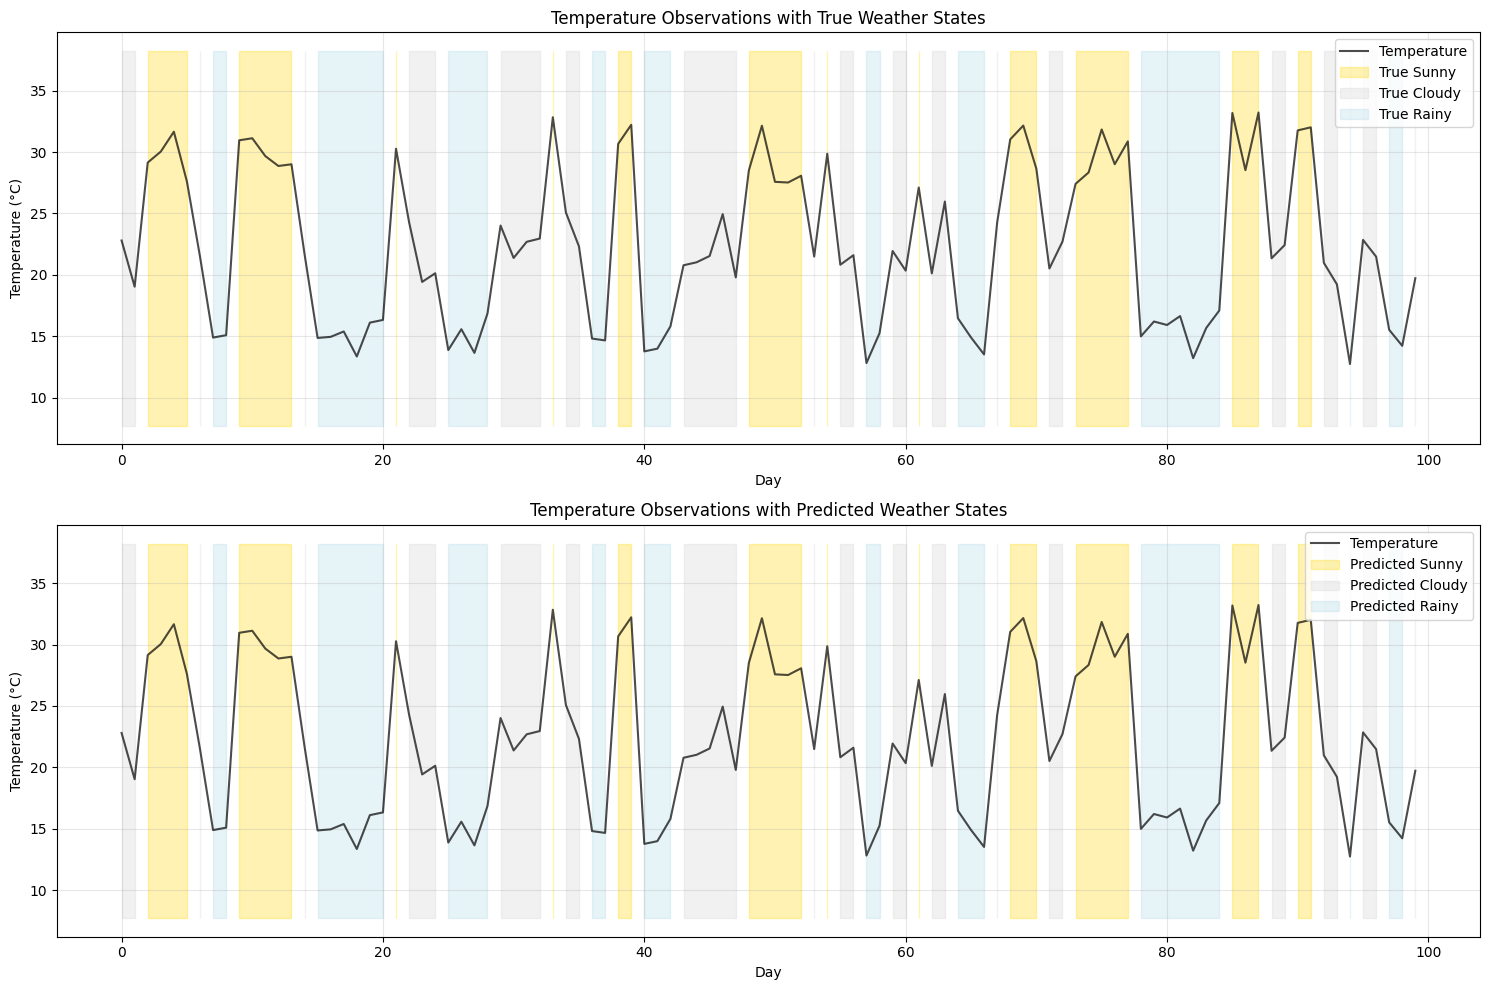

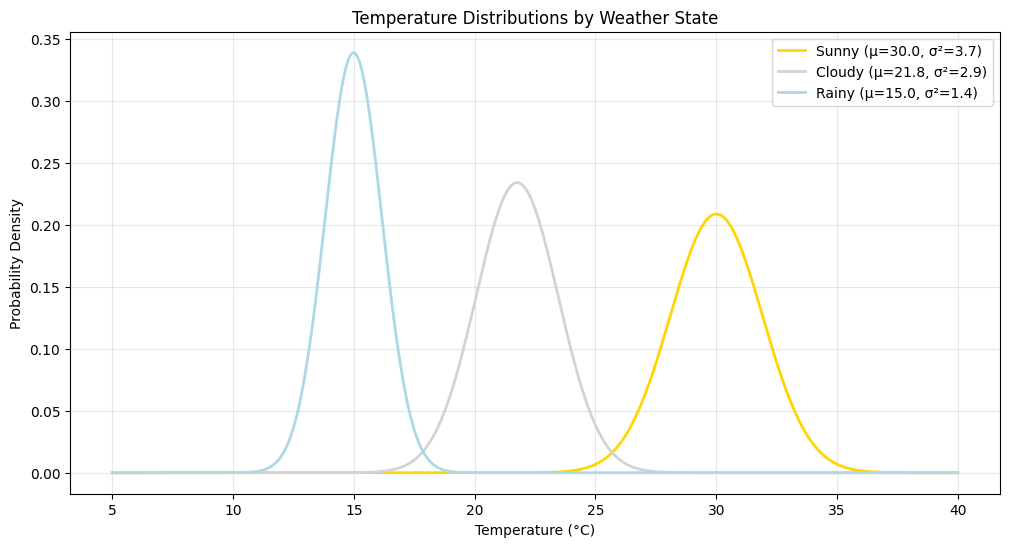

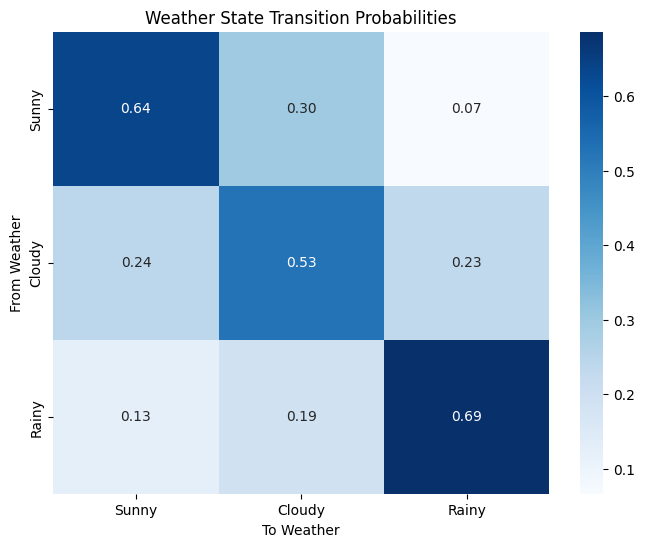

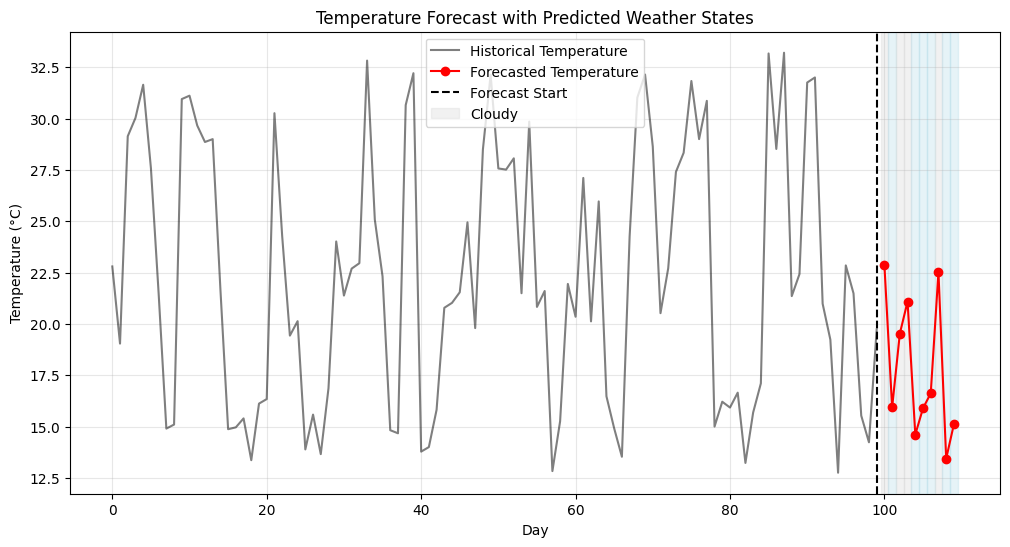

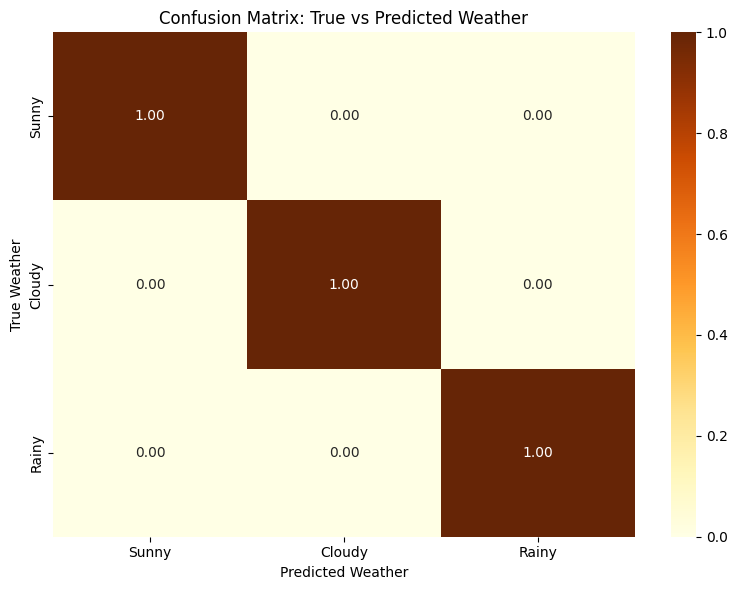


Model Summary:
Learned Temperature Means: Sunny=30.0°C, Cloudy=21.8°C, Rainy=15.0°C
Learned Temperature Variances: Sunny=3.7, Cloudy=2.9, Rainy=1.4

Forecast for the next 10 days:
Day 100: Weather=Cloudy, Temperature=22.9°C
Day 101: Weather=Rainy, Temperature=15.9°C
Day 102: Weather=Cloudy, Temperature=19.5°C
Day 103: Weather=Cloudy, Temperature=21.1°C
Day 104: Weather=Rainy, Temperature=14.6°C
Day 105: Weather=Rainy, Temperature=15.9°C
Day 106: Weather=Rainy, Temperature=16.6°C
Day 107: Weather=Cloudy, Temperature=22.5°C
Day 108: Weather=Rainy, Temperature=13.4°C
Day 109: Weather=Rainy, Temperature=15.1°C


In [18]:
# Run the visualization function
if __name__ == "__main__":
    visualize_gaussian_hmm_results()